# Section 2 — Assignment 2
# Deep Learning with PyTorch

**IOAI 2026 Preparation**

**Topics:** PyTorch Basics, MLPs, Attention Mechanism, Transformers, Adam/AdamW, Batch Normalization, Dropout, Model Finetuning, Embeddings

**Instructions:**
- Write all your code in the empty cells provided below each question.
- You may add extra cells if needed.
- Use **PyTorch** (`torch`, `torch.nn`) throughout unless stated otherwise.
- Answer written questions as comments or in a new markdown cell.

---
## Problem 1 — PyTorch Tensor Basics

1. Create the following tensors in PyTorch:
   - A 3×4 tensor of random floats from a normal distribution.
   - A 4×3 tensor of zeros.
   - A 1-D tensor of integers from 0 to 11 reshaped into shape (3, 4).

2. Perform the following operations:
   - Matrix multiplication between the first and second tensors.
   - Element-wise multiplication between the first and third tensors (cast third to float).
   - Compute the mean along dimension 1 and the sum along dimension 0.

3. Move a tensor to GPU (if available, otherwise keep on CPU). Write code that checks for GPU availability and moves the tensor accordingly.

4. Demonstrate **autograd**: create a tensor with `requires_grad=True`, compute `y = 3x² + 2x + 1`, call `y.sum().backward()`, and print `x.grad`. Verify by computing the derivative analytically.

In [ ]:
import torch

t1 = torch.randn(3, 4)
t2 = torch.zeros(4, 3)
t3 = torch.arange(12).reshape(3, 4).float()

In [ ]:
mat_mul = torch.matmul(t1, t2)
elem_mul = t1 * t3
mean_dim1 = t1.mean(dim=1)
sum_dim0 = t1.sum(dim=0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t1_dev = t1.to(device)

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = 3 * (x**2) + 2 * x + 1

In [ ]:
y.sum().backward()
print(f"x: {x.detach().numpy()}")
print(f"Autograd Gradients (dy/dx): {x.grad.numpy()}")

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [ ]:
analytical = 6 * x.detach() + 2
print(f"Analytical Gradients:{analytical.numpy()}")

Analytical Gradients:[ 8. 14. 20.]


---
## Problem 2 — Multi-Layer Perceptron (MLP) in PyTorch

Build and train an MLP on the **MNIST** dataset (or use `torchvision.datasets.MNIST`).

1. Define an MLP with:
   - Input layer: 784 units (flattened 28×28 image)
   - Hidden layer 1: 512 units, ReLU
   - Hidden layer 2: 256 units, ReLU
   - Output layer: 10 units (digits 0–9)

2. Write a training loop that:
   - Uses `Adam` optimizer with lr=0.001 and Cross-Entropy loss.
   - Trains for 10 epochs on the training set.
   - Evaluates accuracy on the test set after each epoch.
   - Plots training loss and test accuracy over epochs.

3. Use a `DataLoader` with `batch_size=64` and `shuffle=True` for training.

4. Visualize 16 random test samples along with their predicted and true labels (green if correct, red if wrong).

5. What test accuracy do you achieve? What would a random classifier score on this 10-class problem?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_set = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.00MB/s]


In [ ]:
class MNIST_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),)
    def forward(self, x):
        return self.net(x)

In [ ]:
model = MNIST_MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 10
train_losses, test_accs = [], []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Evaluation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    epoch_acc = (correct / total) * 100
    test_accs.append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Test Acc: {epoch_acc:.2f}%")

Epoch 1/10 | Loss: 0.2046 | Test Acc: 96.92%
Epoch 2/10 | Loss: 0.0872 | Test Acc: 97.31%
Epoch 3/10 | Loss: 0.0594 | Test Acc: 96.90%
Epoch 4/10 | Loss: 0.0435 | Test Acc: 97.54%
Epoch 5/10 | Loss: 0.0394 | Test Acc: 97.96%
Epoch 6/10 | Loss: 0.0286 | Test Acc: 98.05%
Epoch 7/10 | Loss: 0.0297 | Test Acc: 97.87%
Epoch 8/10 | Loss: 0.0244 | Test Acc: 97.77%
Epoch 9/10 | Loss: 0.0224 | Test Acc: 97.96%
Epoch 10/10 | Loss: 0.0203 | Test Acc: 98.34%


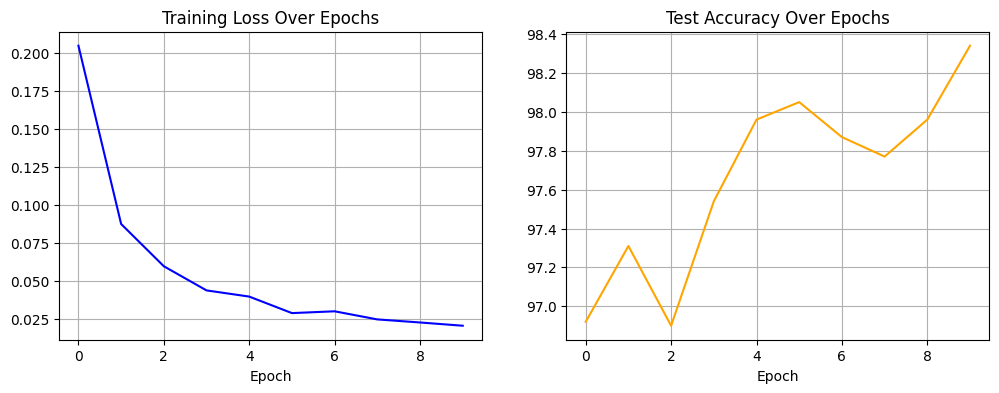

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label="Train Loss", color="blue")
ax1.set_title("Training Loss Over Epochs")
ax1.set_xlabel("Epoch")
ax1.grid(True)

ax2.plot(test_accs, label="Test Accuracy", color="orange")
ax2.set_title("Test Accuracy Over Epochs")
ax2.set_xlabel("Epoch")
ax2.grid(True)
plt.show()

In [ ]:
model.eval()
vis_loader = DataLoader(test_set, batch_size=16, shuffle=True)
images, labels = next(iter(vis_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)
preds = preds.cpu().numpy()
labels = labels.numpy()

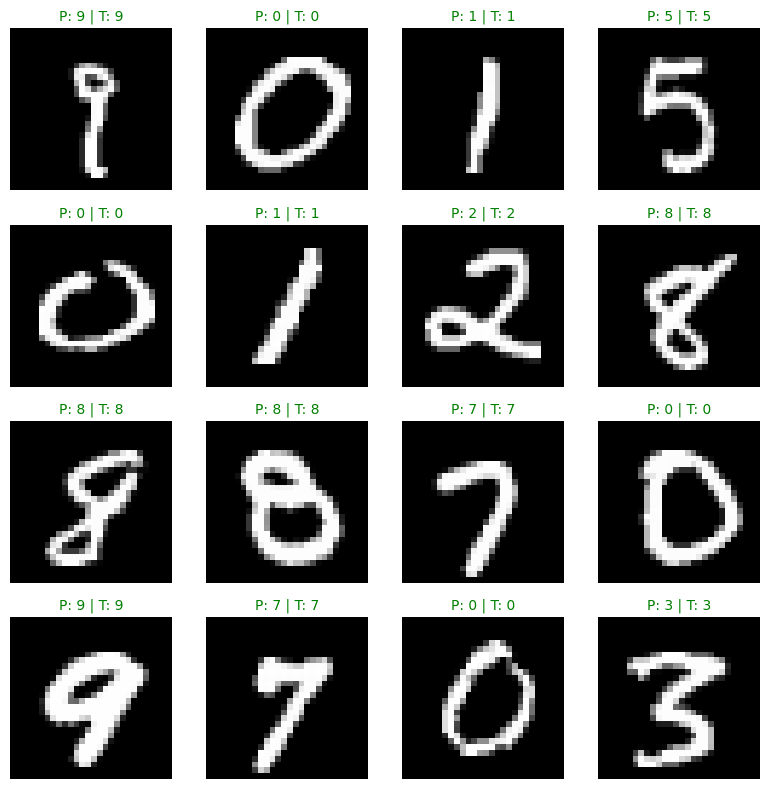

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")

    color = "green" if preds[i] == labels[i] else "red"
    ax.set_title(f"P: {preds[i]} | T: {labels[i]}", color=color, fontsize=10)

plt.tight_layout()
plt.show()

---
## Problem 3 — Regularization: Dropout & Batch Normalization

Using the same MNIST setup from Problem 2:

1. Build three versions of the MLP:
   - **Baseline**: no regularization (same as Problem 2)
   - **Dropout**: add `Dropout(p=0.4)` after each hidden ReLU layer
   - **BatchNorm + Dropout**: add `BatchNorm1d` before each ReLU, and `Dropout(0.3)` after

2. To force overfitting, train all three models on only **1% of the training data** (about 600 samples). Evaluate on the full test set.

3. Plot training loss and test accuracy for all three models on the same graph.

4. Explain the role of `model.train()` vs `model.eval()` — why does it matter for Dropout and BatchNorm?

5. What does BatchNorm do mathematically? Why does it help with training stability and allow higher learning rates?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_set = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform)

In [ ]:
np.random.seed(42)
sub_idx = np.random.choice(len(train_set), 600, replace=False)
train_sub = Subset(train_set, sub_idx)
train_loader = DataLoader(train_sub, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

In [ ]:
class BaselineMLP(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class DropoutMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10),)
    def forward(self, x):
        return self.net(x)

In [ ]:
class BN_DropoutMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10),)
    def forward(self, x):
        return self.net(x)

In [ ]:
def train_model(model_cls):
    model = model_cls().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_hist, acc_hist = [], []
    for epoch in range(40):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        loss_hist.append(running_loss / len(train_loader.dataset))

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        acc_hist.append((correct / total) * 100)

    return loss_hist, acc_hist

In [ ]:
loss_base, acc_base = train_model(BaselineMLP)
loss_drop, acc_drop = train_model(DropoutMLP)
loss_bn, acc_bn = train_model(BN_DropoutMLP)

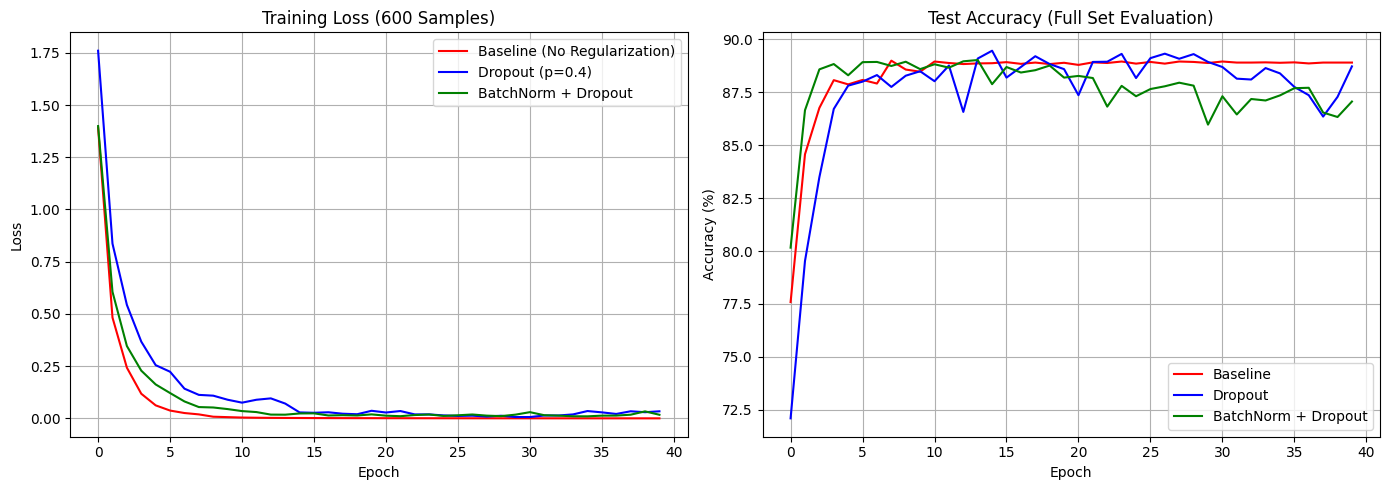

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_base, label="Baseline (No Regularization)", color="red")
ax1.plot(loss_drop, label="Dropout (p=0.4)", color="blue")
ax1.plot(loss_bn, label="BatchNorm + Dropout", color="green")
ax1.set_title("Training Loss (600 Samples)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(acc_base, label="Baseline", color="red")
ax2.plot(acc_drop, label="Dropout", color="blue")
ax2.plot(acc_bn, label="BatchNorm + Dropout", color="green")
ax2.set_title("Test Accuracy (Full Set Evaluation)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

model.train(), versus model.eval()

These switches change how modules work during training and inference:

* Dropout: When we use model.train() some neurons are randomly turned off to make the model more robust.

In model.eval() dropout is turned off so the whole network is used for predictions.

* BatchNorm: With model.train() it calculates the mean and variance using the mini-batch.

In model.eval() it stops updating. Uses a saved average to make predictions.

Training Stability

* It helps to keep the data that deep layers get consistent so they do not have to deal with changes, from early layers.

Higher Learning Rates

* It stops the activations from going to flat areas. This keeps the gradients clear and steady.

* We can use a learning rate because the network does not get unstable.

---
## Problem 4 — Optimizers: SGD vs Adam vs AdamW

1. Train the MLP from Problem 2 using three different optimizers:
   - `SGD` with lr=0.01 and momentum=0.9
   - `Adam` with lr=0.001
   - `AdamW` with lr=0.001 and weight_decay=0.01

2. For each optimizer, experiment with two learning rate schedules:
   - **Constant** (no scheduler)
   - **StepLR**: reduce lr by factor 0.5 every 3 epochs

3. Plot all six training loss curves on the same graph. Which combination converges fastest?

4. What is the difference between **L2 regularization** and **weight decay** in Adam? Why does AdamW fix a bug in the original Adam + L2 combination?

5. When would you prefer SGD with momentum over Adam? Name a real-world scenario (e.g., a specific type of model or training regime) where SGD is commonly preferred.

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_set = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

In [ ]:
def get_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 10),
    ).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
epochs = 10
configs = [
    ("SGD Constant", optim.SGD, {"lr": 0.01, "momentum": 0.9}, False),
    ("SGD StepLR", optim.SGD, {"lr": 0.01, "momentum": 0.9}, True),
    ("Adam Constant", optim.Adam, {"lr": 0.001}, False),
    ("Adam StepLR", optim.Adam, {"lr": 0.001}, True),
    ("AdamW Constant", optim.AdamW, {"lr": 0.001, "weight_decay": 0.01}, False),
    ("AdamW StepLR", optim.AdamW, {"lr": 0.001, "weight_decay": 0.01}, True),
]
results = {}

In [ ]:
for name, opt_cls, kwargs, use_sched in configs:
    model = get_model()
    optimizer = opt_cls(model.parameters(), **kwargs)
    scheduler = StepLR(optimizer, step_size=3, gamma=0.5) if use_sched else None
    loss_history = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        if scheduler:
            scheduler.step()
        epoch_loss = running_loss / len(train_loader.dataset)
        loss_history.append(epoch_loss)
    results[name] = loss_history

Adam Constant or AdamW Constant usually works best at first on MNIST.
MNIST is a dataset so Adams special learning rates for each part help it learn fast.
It moves quickly down the gradient surface because of this, which's better, than simple SGD.

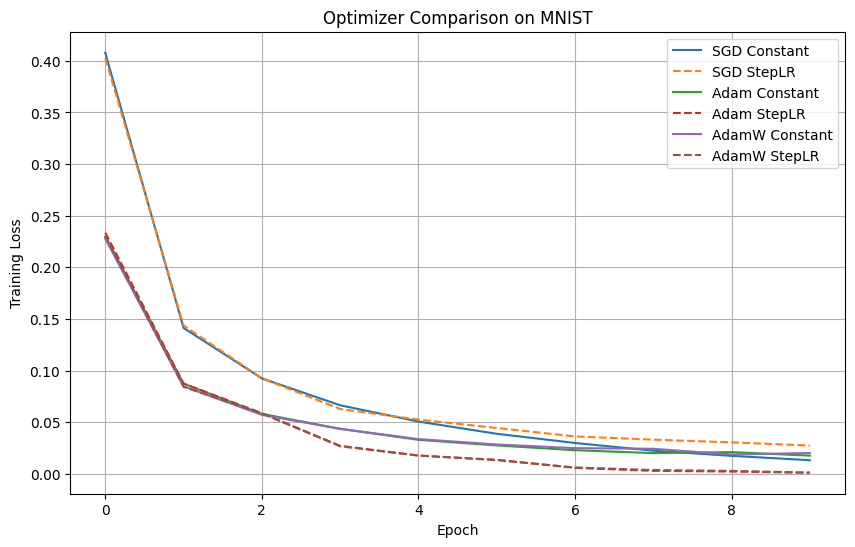

In [ ]:
plt.figure(figsize=(10, 6))
for name, losses in results.items():
    style = "--" if "StepLR" in name else "-"
    plt.plot(losses, label=name, linestyle=style)

plt.title("Optimizer Comparison on MNIST")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

When we really need to get the results on a tough test set we should use SGD with Momentum. This is the choice when we want your model to work really well and we have a lot of time to train it. SGD, with Momentum is the way to go if we want the best performance and we do not mind waiting for a long time to get it.

---
## Problem 5 — Scaled Dot-Product Attention From Scratch

1. Implement the **scaled dot-product attention** mechanism using PyTorch tensors:

   Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V

   Your function should accept Query, Key, and Value matrices and return the attention output and the attention weights.

2. Test it with random Q, K, V tensors of shape (batch=2, seq_len=5, d_k=8). Print the output shape and visualize the attention weight matrix as a heatmap.

3. Implement **Multi-Head Attention** (with 4 heads) by splitting Q, K, V into heads, applying attention separately, and concatenating the results.

4. Implement an **attention mask** to prevent a position from attending to future positions (causal masking). Apply it to a sequence of length 6 and show the resulting masked attention weights.

5. Why is the scaling factor √d_k important? What happens to the softmax output when dot products grow very large (hint: what region of softmax does this push the scores into)?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


In [ ]:
def attention(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, v)
    return output, weights

Single-Head Output Shape: torch.Size([2, 5, 8])


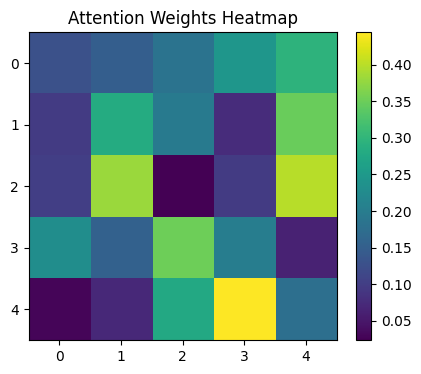

In [ ]:
q = torch.randn(2, 5, 8)
k = torch.randn(2, 5, 8)
v = torch.randn(2, 5, 8)
out, weights = attention(q, k, v)
print(f"Single-Head Output Shape: {out.shape}")
plt.figure(figsize=(5, 4))
plt.imshow(weights[0].detach().numpy(), cmap="viridis")
plt.title("Attention Weights Heatmap")
plt.colorbar()
plt.show()

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=16, heads=4):
        super().__init__()
        self.heads = heads
        self.d_k = d_model // heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
    def forward(self, q, k, v, mask=None):
        batch = q.size(0)
        q = self.w_q(q).view(batch, -1, self.heads, self.d_k).transpose(1, 2)
        k = self.w_k(k).view(batch, -1, self.heads, self.d_k).transpose(1, 2)
        v = self.w_v(v).view(batch, -1, self.heads, self.d_k).transpose(1, 2)
        out, weights = attention(q, k, v, mask)
        out = out.transpose(1, 2).contiguous().view(batch, -1, self.heads * self.d_k)
        return self.w_o(out)

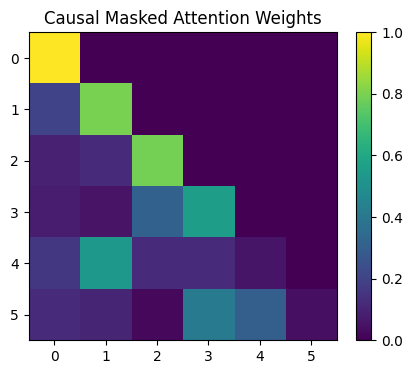

In [ ]:
seq_len = 6
causal_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0)
q_mask = torch.randn(1, seq_len, 8)
k_mask = torch.randn(1, seq_len, 8)
v_mask = torch.randn(1, seq_len, 8)
_, masked_weights = attention(q_mask, k_mask, v_mask, mask=causal_mask)
plt.figure(figsize=(5, 4))
plt.imshow(masked_weights[0].detach().numpy(), cmap="viridis")
plt.title("Causal Masked Attention Weights")
plt.colorbar()
plt.show()

Without the $\sqrt{d_k}$ scaling factor the embedding dimensions get really big. This makes the dot products get very large in value.

This is a problem because it pushes the scores way into the parts of the softmax function.

When this happens the softmax function starts working like it picks the highest score so it gives that one a 1 and everything else gets a 0.

The gradients in these flat parts are almost zero, which completely stops the training because the gradients are too small, during backpropagation.

---
## Problem 6 — Embeddings & Model Finetuning

**Part A — Embeddings:**

1. Create a word embedding layer using `nn.Embedding(vocab_size=1000, embedding_dim=64)`. Pass a batch of integer token indices through it and print the output shape.

2. Train a simple MLP text classifier using embeddings: mean-pool the token embeddings to get a sentence representation, then pass through two linear layers to classify into 2 classes. Use synthetic integer token sequences.

**Part B — Transfer Learning & Finetuning:**

3. Load a pretrained model from `torchvision.models` (e.g., `resnet18(pretrained=True)`). Freeze all layers except the final fully connected layer. Replace the final layer to output 2 classes.

4. Train only the final layer for 5 epochs on a small binary image dataset (you can use a subset of CIFAR-10: e.g., cats vs dogs). Compare against training the full network from scratch for the same number of epochs.

5. What is **parameter-efficient finetuning**? What is **LoRA** and how does it differ from full finetuning? When is it preferable?

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, models, transforms

In [ ]:
vocab_size = 1000
embedding_dim = 64
emb_layer = nn.Embedding(vocab_size, embedding_dim)

In [ ]:
dummy_indices = torch.randint(0, vocab_size, (4, 10))
emb_output = emb_layer(dummy_indices)
print(f"Embedding Input Shape:  {dummy_indices.shape}")
print(f"Embedding Output Shape: {emb_output.shape}")

Embedding Input Shape:  torch.Size([4, 10])
Embedding Output Shape: torch.Size([4, 10, 64])


In [ ]:
class TextClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Sequential(
            nn.Linear(embedding_dim, 32), nn.ReLU(), nn.Linear(32, 2))
    def forward(self, x):
        # x shape: [batch, seq_len]
        embedded = self.embedding(x)  # [batch, seq_len, emb_dim]
        pooled = embedded.mean(dim=1)  # [batch, emb_dim]
        return self.fc(pooled)  # [batch, 2]

In [ ]:
X_text = torch.randint(0, vocab_size, (200, 15))
y_text = torch.randint(0, 2, (200,))
text_loader = DataLoader(
    TensorDataset(X_text, y_text), batch_size=32, shuffle=True)
text_model = TextClassifier()
text_opt = optim.Adam(text_model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
for epoch in range(3):
    for tokens, labels in text_loader:
        text_opt.zero_grad()
        loss = criterion(text_model(tokens), labels)
        loss.backward()
        text_opt.step()
print("Text classifier trained successfully.\n")

Text classifier trained successfully.



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),])
cifar_train = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:05<00:00, 30.9MB/s]


In [ ]:
idx = [i for i, label in enumerate(cifar_train.targets) if label in [0, 1]][:200]
sub_train = torch.utils.data.Subset(cifar_train, idx)

In [ ]:
for i in idx:
    cifar_train.targets[i] = 0 if cifar_train.targets[i] == 0 else 1
img_loader = DataLoader(sub_train, batch_size=32, shuffle=True)

In [ ]:
def train_img_model(model, name):
    model = model.to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    print(f"Training {name}")
    for epoch in range(5):
        running_loss = 0.0
        for images, labels in img_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        print(f"Epoch {epoch+1}/5 | Loss: {running_loss / len(sub_train):.4f}")

In [ ]:
frozen_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in frozen_resnet.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


In [ ]:
frozen_resnet.fc = nn.Linear(frozen_resnet.fc.in_features, 2)
train_img_model(frozen_resnet, "Frozen ResNet (Pretrained)")
scratch_resnet = models.resnet18(weights=None)
scratch_resnet.fc = nn.Linear(scratch_resnet.fc.in_features, 2)
train_img_model(scratch_resnet, "Scratch ResNet (Random Init)")

Training Frozen ResNet (Pretrained)
Epoch 1/5 | Loss: 0.6446
Epoch 2/5 | Loss: 0.4802
Epoch 3/5 | Loss: 0.3807
Epoch 4/5 | Loss: 0.3406
Epoch 5/5 | Loss: 0.2783
Training Scratch ResNet (Random Init)
Epoch 1/5 | Loss: 0.9187
Epoch 2/5 | Loss: 0.5488
Epoch 3/5 | Loss: 0.4371
Epoch 4/5 | Loss: 0.3585
Epoch 5/5 | Loss: 0.3183


I like to use LoRA when I am training models and I do not have a lot of video memory. This is also helpful when I want to use different models on the same computer. LoRA is also good when I have an amount of data and I do not want my LoRA models to get too used, to that data.

PEFT freezes, than 99 percent of a pretrained models weights and only tunes a very small part. This really cuts down on the storage space that is needed for checkpoints. It also stops the network from forgetting the things it originally knew about the pretrained model. The pretrained model is able to keep its knowledge because of this.

---
## Reflection Questions

Answer in a markdown cell or as comments:

1. What is the purpose of the `requires_grad` flag in PyTorch? What happens if you forget to zero gradients (`optimizer.zero_grad()`) between batches?
2. Dropout is disabled at inference time. Explain why, and describe how **MC Dropout** repurposes it for uncertainty estimation.
3. The Transformer uses positional encodings. Why are they necessary if attention is permutation-equivariant? What is the difference between sinusoidal and learned positional encodings?
4. When finetuning a large pretrained model on a small dataset, why is freezing early layers a good idea? What do early layers typically learn?

1. PyTorch needs to track what happens to a tensor so it can figure out its gradients later. This is what requires_grad does. If we set requires_grad to False PyTorch will use memory because it does not have to track the gradients.

   If we do not use zero_grad PyTorch will just keep adding up all the gradients every time we call.backward. This is a problem because the gradients from the batch will get mixed up with the gradients, from the previous batches. This will cause the updates to go in the direction and the training will not work.

2.
   Why is dropout disabled?

   Dropout kills neurons randomly. This helps prevent overfitting during training. At inference time we want predictions that're always the same and use full capacity. So we use all neurons. Adjust their weights to match.

   MC Dropout is different. we keep dropout on during inference. Then we run the input through the network many times. Each time different neurons drop out. This gives us slightly different outputs. The variation in these outputs shows how unsure the model is, about its prediction.


3. Self-attention looks at inputs like a bunch of words—it does not know the order. If you mix up a sentence the attention outputs do not change. Positional encodings add order to the word embeddings so the model knows where each word is.

4. It prevents overfitting on small datasets and cuts down on training time and VRAM usage.